# Phase 0: Data Layer Lockdown

Validate each deliverable interactively before graduating logic to `src/data_prep.py`.

## Order of operations

1. Diagnose the `pos_GK` / `pos_GKP` inconsistency
2. Quantify new-player coverage for cluster strategy (a)
3. Build stage-1 labels (`played_60min`, `played_any`) from pre-DGW data
4. Fit K-means on playing-style features (train-only)
5. Define feature groups and train/val/test masks
6. Sanity-check Ridge baseline against the updated dataset

Sections 1–2 are diagnostic. Sections 3–6 get fleshed out once the diagnostics have been read.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = PROJECT_ROOT / "data" / "raw"
PROCESSED = PROJECT_ROOT / "data" / "processed"
SEASONS = ["2021-22", "2022-23", "2023-24"]

assert RAW.exists(), f"Missing: {RAW}"
assert PROCESSED.exists(), f"Missing: {PROCESSED}"

In [2]:
df = pd.read_csv(PROCESSED / "fpl_modeling_data.csv", low_memory=False)
df.shape
df["position"] = df["position"].replace({"GKP": "GK"})

In [3]:
import unicodedata

def strip_accents(s: str) -> str:
    if pd.isna(s):
        return s
    return "".join(c for c in unicodedata.normalize("NFKD", s) if not unicodedata.combining(c))

# Use this normalized form for all cross-season joins
df["name_key"] = df["name"].astype(str).map(strip_accents).str.lower().str.strip()

## 1. Position encoding diagnosis

The progress report's position distribution shows both `pos_GK` and `pos_GKP` columns. Find the source season(s) and the underlying string mismatch before fixing.

In [4]:
# Confirm the bug in the existing processed table
pos_cols = [c for c in df.columns if c.startswith("pos_")]
print("position one-hots:", pos_cols)

for col in pos_cols:
    by_season = df[df[col] == 1]["season"].value_counts().sort_index()
    print(f"\n{col}=1 by season:")
    print(by_season.to_string())

position one-hots: ['pos_DEF', 'pos_FWD', 'pos_GK', 'pos_GKP', 'pos_MID']

pos_DEF=1 by season:
season
2021-22    7603
2022-23    8360
2023-24    9018

pos_FWD=1 by season:
season
2021-22    2991
2022-23    2838
2023-24    3613

pos_GK=1 by season:
season
2021-22    2486
2022-23    2537
2023-24    3197

pos_GKP=1 by season:
season
2021-22    80

pos_MID=1 by season:
season
2021-22     9299
2022-23    10410
2023-24    12045


In [5]:
# Trace to raw: which season uses which string?
for season in SEASONS:
    raw = pd.read_csv(RAW / season / "merged_gw.csv", low_memory=False)
    if "position" in raw.columns:
        vals = sorted(raw["position"].dropna().unique())
        print(f"{season}: position values = {vals}")
    elif "element_type" in raw.columns:
        vals = sorted(raw["element_type"].dropna().unique())
        print(f"{season}: no `position` col, element_type values = {vals}")
    else:
        print(f"{season}: no position-bearing column")

2021-22: position values = ['DEF', 'FWD', 'GK', 'GKP', 'MID']
2022-23: position values = ['DEF', 'FWD', 'GK', 'MID']
2023-24: position values = ['DEF', 'FWD', 'GK', 'MID']


### Diagnosis

2021-22: position values = ['DEF', 'FWD', 'GK', 'GKP', 'MID']
2022-23: position values = ['DEF', 'FWD', 'GK', 'MID']
2023-24: position values = ['DEF', 'FWD', 'GK', 'MID']


pos_GKP=1 by season:
season
2021-22    80

Seems like issue lied in with the fact that season 21/22 used GKP at times for GK


## 2. New-player coverage for cluster strategy (a)

Strategy (a) assigns 23/24 player-seasons to clusters using their 21/22 and/or 22/23 aggregates. Players new to the league need a fallback (position + price tier).

We need the size of the fallback population both by headcount **and** by minutes — a 30-GW starter with no prior history hurts more than a one-off bench appearance.

Caveat: matching by `name` across seasons is imperfect (accents, hyphens, name changes). vaastav's data is generally consistent but flag if numbers look wrong.

In [6]:
import unicodedata

def normalize_name(s: str) -> str:
    if pd.isna(s):
        return s
    stripped = "".join(
        c for c in unicodedata.normalize("NFKD", str(s))
        if not unicodedata.combining(c)
    )
    return stripped.lower().strip()

def player_season_summary(season: str) -> pd.DataFrame:
    raw = pd.read_csv(RAW / season / "merged_gw.csv", low_memory=False)
    raw["name_key"] = raw["name"].map(normalize_name)
    return (
        raw.groupby("name_key", as_index=False)
           .agg(
               name=("name", "first"),     # keep a display name for inspection
               gws=("GW", "nunique"),
               mins=("minutes", "sum"),
           )
    )

prior = pd.concat(
    [player_season_summary(s) for s in ["2021-22", "2022-23"]],
    ignore_index=True,
)
prior = prior.groupby("name_key", as_index=False).agg(
    prior_gws=("gws", "max"),
    prior_mins=("mins", "sum"),
)

current = (
    player_season_summary("2023-24")
    .merge(prior, on="name_key", how="left")
    .fillna({"prior_gws": 0, "prior_mins": 0})
    .astype({"prior_gws": int, "prior_mins": int})
)

played = current[current["mins"] > 0].copy()
n = len(played)
total_mins = played["mins"].sum()

rows = [
    ("no prior history", played["prior_gws"] == 0),
    ("<5 prior GWs",     played["prior_gws"] < 5),
    ("<10 prior GWs",    played["prior_gws"] < 10),
    (">=20 prior GWs",   played["prior_gws"] >= 20),
]

print(f"23/24 players with >0 minutes: {n}\n")
print(f"{'bucket':<22}{'players':>10}{'pct':>8}{'mins share':>14}")
for label, mask in rows:
    headcount_pct = mask.mean()
    mins_pct = played.loc[mask, "mins"].sum() / total_mins
    print(f"{label:<22}{mask.sum():>10}{headcount_pct:>8.1%}{mins_pct:>14.1%}")

23/24 players with >0 minutes: 573

bucket                   players     pct    mins share
no prior history             169   29.5%         23.6%
<5 prior GWs                 170   29.7%         23.6%
<10 prior GWs                170   29.7%         23.6%
>=20 prior GWs               369   64.4%         71.3%


In [7]:
# Confirm specific players are no longer flagged as "no prior history"
test_names = ["Vladimír Coufal", "Tomáš Souček"]
test_keys = [normalize_name(n) for n in test_names]
print(played[played["name_key"].isin(test_keys)][["name", "name_key", "prior_gws", "prior_mins", "mins"]].to_string(index=False))

           name        name_key  prior_gws  prior_mins  mins
   Tomáš Souček    tomas soucek         37        5872  2867
Vladimír Coufal vladimir coufal         37        4342  3135


### Verdict

23/24 players with >0 minutes: 573

bucket                   players     pct    mins share
no prior history             175   30.5%         24.9%
<5 prior GWs                 176   30.7%         25.0%
<10 prior GWs                176   30.7%         25.0%
leq 20 prior GWs               364   63.5%         70.1%

Decision rule:
- **no-prior-history minutes share < ~15%** → strategy (a) with a simple `position + price-tier` fallback is fine.
- **15–30%** → the fallback needs more thought (e.g. `team strength + position + price tier`).
- **> 30%** → reconsider strategy (b) seriously.

In [8]:
# Sample the 175 "no prior history" players and look for obvious name-match failures
sample = (
    played[played["prior_gws"] == 0]
    .sort_values("mins", ascending=False)   # high-minute "rookies" are most suspicious
    .head(40)
)

# Pull team info from raw 23/24 data for context
raw_24 = pd.read_csv(RAW / "2023-24" / "merged_gw.csv", low_memory=False)
team_lookup = raw_24.groupby("name", as_index=False).agg(team=("team", "first"))
sample = sample.merge(team_lookup, on="name", how="left")

print(sample[["name", "team", "gws", "mins"]].to_string(index=False))

                             name          team  gws  mins
                      André Onana       Man Utd   37  3420
                Guglielmo Vicario         Spurs   36  3420
                  Thomas Kaminski         Luton   35  3405
                     Mark Flekken     Brentford   37  3285
                     Sander Berge       Burnley   37  3002
                    Alfie Doughty         Luton   35  2923
                    Gustavo Hamer Sheffield Utd   36  2908
                      Dara O'Shea       Burnley   37  2892
                    Jack Robinson Sheffield Utd   37  2883
                   Carlton Morris         Luton   35  2859
                  Nicolas Jackson       Chelsea   36  2801
Murillo Santiago Costa dos Santos Nott'm Forest   35  2790
                     Jayden Bogle Sheffield Utd   37  2787
              Vini de Souza Costa Sheffield Utd   37  2664
                 Anel Ahmedhodžić Sheffield Utd   37  2649
                  Wes Foderingham Sheffield Utd   37  26

## 3. Stage-1 labels: `played_60min` and `played_any`

Computed from **raw** (pre-DGW-aggregation) data so the per-fixture max rule applies correctly to DGWs.

Rules:
- `played_any = 1` iff the player got > 0 minutes in **any** fixture that GW.
- `played_60min = 1` iff the player crossed 60 minutes in **any single** fixture that GW. Matches FPL's appearance/CS bonus structure: 60 minutes in one fixture earns the 2-pt bonus and CS eligibility regardless of what happened in the other DGW fixture.

Note: this differs from the spec's "summed minutes ≥ 60" — we deliberately chose max-per-fixture because it maps to actual FPL points logic. A 45+45 DGW does NOT cross the threshold; a 75+0 DGW does.

In [9]:
def compute_stage1_labels(season: str) -> pd.DataFrame:
    raw = pd.read_csv(RAW / season / "merged_gw.csv", low_memory=False)
    raw["name_key"] = raw["name"].map(normalize_name)
    raw["season"] = season
    raw["crossed_60"] = (raw["minutes"] >= 60).astype(int)
    raw["any_mins"]   = (raw["minutes"] > 0).astype(int)

    # Aggregate fixture rows -> player-GW level. Max gives us the per-fixture rule.
    return (
        raw.groupby(["name_key", "season", "GW"], as_index=False)
           .agg(
               played_60min=("crossed_60", "max"),
               played_any=("any_mins", "max"),
               n_fixtures=("minutes", "size"),
               total_minutes=("minutes", "sum"),
           )
    )

labels = pd.concat([compute_stage1_labels(s) for s in SEASONS], ignore_index=True)
labels.shape, labels.head()

((76858, 7),
          name_key   season  GW  played_60min  played_any  n_fixtures  total_minutes
 0  aaron connolly  2021-22   1             0           0           1              0
 1  aaron connolly  2021-22   2             0           1           1             45
 2  aaron connolly  2021-22   3             0           0           1              0
 3  aaron connolly  2021-22   4             0           0           1              0
 4  aaron connolly  2021-22   5             0           0           1              0)

In [10]:
# Add name_key to processed data so we can merge cleanly
df["name_key"] = df["name"].map(normalize_name)

# Verify every (name_key, season, GW) in df has a label row in raw
df_keys = set(map(tuple, df[["name_key", "season", "GW"]].values))
lbl_keys = set(map(tuple, labels[["name_key", "season", "GW"]].values))
missing = df_keys - lbl_keys
assert len(missing) == 0, f"Missing label rows for {len(missing)} keys; sample: {list(missing)[:5]}"

df = df.merge(
    labels[["name_key", "season", "GW", "played_60min", "played_any", "n_fixtures"]],
    on=["name_key", "season", "GW"],
    how="left",
    validate="one_to_one",
)
# Treat n_fixtures as the canonical DGW signal going forward
df["is_dgw"] = (df["n_fixtures"] >= 2).astype(int)

# Acceptance checks
assert df["played_60min"].isna().sum() == 0
assert df["played_any"].isna().sum() == 0
assert set(df["played_60min"].unique()) <= {0, 1}
assert set(df["played_any"].unique()) <= {0, 1}
assert df.shape[0] == 74477, f"Row count changed: {df.shape[0]}"

print(f"Shape: {df.shape}")
print(f"\nplayed_any distribution:    {df['played_any'].mean():.3f} (share = 1)")
print(f"played_60min distribution:  {df['played_60min'].mean():.3f} (share = 1)")
print(f"\nLabel sanity (subset, played_60min=1 must imply played_any=1):")
print(f"  rows with 60min=1 but any=0: {((df['played_60min'] == 1) & (df['played_any'] == 0)).sum()}")

Shape: (74477, 56)

played_any distribution:    0.412 (share = 1)
played_60min distribution:  0.295 (share = 1)

Label sanity (subset, played_60min=1 must imply played_any=1):
  rows with 60min=1 but any=0: 0


In [11]:
# DGW rows where the per-fixture-max rule and summed-minutes rule disagree.
# Computed entirely from `labels` since it has n_fixtures + total_minutes.
dgw_labels = labels[labels["n_fixtures"] >= 2].copy()
dgw_labels["sum_rule_60"] = (dgw_labels["total_minutes"] >= 60).astype(int)
disagreements = dgw_labels[dgw_labels["played_60min"] != dgw_labels["sum_rule_60"]]

print(f"DGW rows: {len(dgw_labels)}")
print(f"Disagreements (per-fixture-max vs summed-minutes): {len(disagreements)}")
print(f"\nSample disagreements (these justify the per-fixture-max rule):")
cols = ["name_key", "season", "GW", "total_minutes", "sum_rule_60", "played_60min"]
print(disagreements[cols].head(10).to_string(index=False))

DGW rows: 4808
Disagreements (per-fixture-max vs summed-minutes): 33

Sample disagreements (these justify the per-fixture-max rule):
          name_key  season  GW  total_minutes  sum_rule_60  played_60min
     cedric soares 2021-22  33             74            1             0
        diogo jota 2021-22  29             80            1             0
      joe gelhardt 2021-22  26             74            1             0
      joe gelhardt 2021-22  28             72            1             0
        lewis bate 2021-22  36            103            1             0
        lukas rupp 2021-22  36            102            1             0
     mateusz klich 2021-22  36             76            1             0
        rico henry 2021-22  22             74            1             0
ruben loftus-cheek 2021-22  28             65            1             0
  shandon baptiste 2021-22  21             84            1             0


In [12]:
print(sorted(df.columns.tolist()))
# Look for anything DGW-ish that might be there under a different name
print([c for c in df.columns if "dgw" in c.lower() or "fixture" in c.lower() or "double" in c.lower()])

['GW', 'assists_lag1', 'assists_roll3', 'bonus_lag1', 'bonus_roll3', 'bps_lag1', 'bps_roll3', 'clean_sheets_lag1', 'clean_sheets_roll3', 'creativity_lag1', 'creativity_roll3', 'goals_conceded_lag1', 'goals_conceded_roll3', 'goals_scored_lag1', 'goals_scored_roll3', 'gws_played', 'ict_index_lag1', 'ict_index_roll3', 'influence_lag1', 'influence_roll3', 'is_dgw', 'minutes_lag1', 'minutes_roll3', 'n_fixtures', 'name', 'name_key', 'opponent_team', 'played_60min', 'played_any', 'player_season', 'pos_DEF', 'pos_FWD', 'pos_GK', 'pos_GKP', 'pos_MID', 'position', 'red_cards_lag1', 'red_cards_roll3', 'saves_lag1', 'saves_roll3', 'season', 'selected', 'team', 'threat_lag1', 'threat_roll3', 'total_points', 'total_points_lag1', 'total_points_roll3', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'xP', 'yellow_cards_lag1', 'yellow_cards_roll3']
['n_fixtures', 'is_dgw']


In [13]:
# Normalize position string and regenerate one-hots
df["position"] = df["position"].replace({"GKP": "GK"})
df = df.drop(columns=[c for c in df.columns if c.startswith("pos_")])
df = pd.concat(
    [df, pd.get_dummies(df["position"], prefix="pos").astype(int)],
    axis=1,
)

# Acceptance: one-hots sum to 1 for every row, exactly 4 columns
pos_cols = sorted(c for c in df.columns if c.startswith("pos_"))
print(f"position one-hots: {pos_cols}")
assert (df[pos_cols].sum(axis=1) == 1).all(), "pos_* one-hots do not sum to 1"
print(f"shape: {df.shape}")
print(f"position string distribution:\n{df['position'].value_counts().to_string()}")

position one-hots: ['pos_DEF', 'pos_FWD', 'pos_GK', 'pos_MID']
shape: (74477, 55)
position string distribution:
position
MID    31754
DEF    24981
FWD     9442
GK      8300


## 4. K-means on playing-style features (train-only)

Cluster player-seasons by playing style, not by scoring tier. Features:
- `mean_influence_per_appearance` (sum of influence / GWs played)
- `mean_creativity_per_appearance`
- `mean_threat_per_appearance`
- `mean_minutes_per_GW` (sum of minutes / GWs played)
- `mean_value` (mean of `value` across the season)
- position one-hots

Total points is deliberately excluded — we want archetypes, not "high-scorers vs low-scorers."

Player-season filter: ≥5 GWs played. Bench-warmer noise hurts centroid stability and those players will fall into the unclassified bucket anyway.

Data scope: K-means is fit on **21/22 + 22/23 only**. 23/24 player-seasons get assigned post-hoc via nearest centroid, with the unclassified bucket for new-to-PL players.

In [14]:
def player_season_aggregates(season: str) -> pd.DataFrame:
    """Per-player season-level aggregates of playing-style features."""
    raw = pd.read_csv(RAW / season / "merged_gw.csv", low_memory=False)
    raw["name_key"] = raw["name"].map(normalize_name)
    raw["played"] = (raw["minutes"] > 0).astype(int)

    # Aggregate fixture rows -> player-season
    agg = (
        raw.groupby("name_key", as_index=False)
           .agg(
               name=("name", "first"),
               position=("position", "first"),
               gws_played=("played", "sum"),
               total_minutes=("minutes", "sum"),
               total_influence=("influence", "sum"),
               total_creativity=("creativity", "sum"),
               total_threat=("threat", "sum"),
               mean_value=("value", "mean"),
           )
    )
    # Normalize GKP -> GK at this layer too (we're loading raw)
    agg["position"] = agg["position"].replace({"GKP": "GK"})

    # Per-appearance / per-GW rates (avoid div-by-zero with the >=5 filter below)
    agg["mean_minutes_per_gw"]    = agg["total_minutes"]    / agg["gws_played"].clip(lower=1)
    agg["mean_influence_per_app"] = agg["total_influence"]  / agg["gws_played"].clip(lower=1)
    agg["mean_creativity_per_app"]= agg["total_creativity"] / agg["gws_played"].clip(lower=1)
    agg["mean_threat_per_app"]    = agg["total_threat"]     / agg["gws_played"].clip(lower=1)

    agg["season"] = season
    agg["player_season"] = agg["name_key"] + "_" + season
    return agg

train_agg = pd.concat(
    [player_season_aggregates(s) for s in ["2021-22", "2022-23"]],
    ignore_index=True,
)

# Filter: only player-seasons with meaningful sample size
train_agg = train_agg[train_agg["gws_played"] >= 5].copy()

# Add position one-hots
train_agg = pd.concat(
    [train_agg, pd.get_dummies(train_agg["position"], prefix="pos").astype(int)],
    axis=1,
)

# Determinism: sort by player_season before any fitting
train_agg = train_agg.sort_values("player_season").reset_index(drop=True)

print(f"Train player-seasons (>=5 GWs): {len(train_agg)}")
print(f"\nFeature distribution by position:")
print(train_agg.groupby("position")[
    ["mean_minutes_per_gw", "mean_influence_per_app",
     "mean_creativity_per_app", "mean_threat_per_app", "mean_value"]
].mean().round(2))

Train player-seasons (>=5 GWs): 920

Feature distribution by position:
          mean_minutes_per_gw  mean_influence_per_app  mean_creativity_per_app  mean_threat_per_app  mean_value
position                                                                                                       
DEF                     73.49                   15.21                     6.93                 5.71       46.50
FWD                     52.99                   11.41                     8.17                20.29       66.06
GK                      88.87                   22.25                     0.21                 0.01       47.39
MID                     58.20                   11.68                    11.72                11.25       55.19


K=2: inertia=6099.4, silhouette=0.319
K=3: inertia=4723.4, silhouette=0.386
K=4: inertia=3538.4, silhouette=0.447
K=5: inertia=2632.8, silhouette=0.451
K=6: inertia=2217.2, silhouette=0.430
K=7: inertia=1941.3, silhouette=0.430
K=8: inertia=1730.1, silhouette=0.376
K=9: inertia=1565.3, silhouette=0.365
K=10: inertia=1416.2, silhouette=0.377


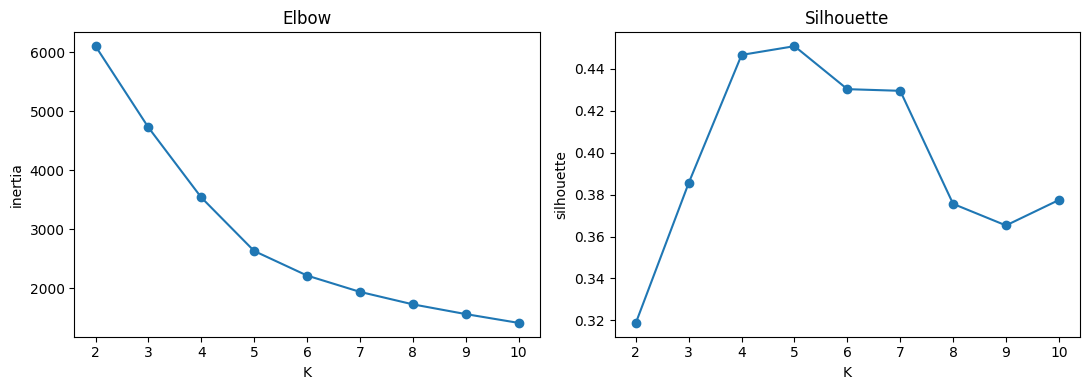

In [15]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

KMEANS_FEATURES = [
    "mean_minutes_per_gw",
    "mean_influence_per_app",
    "mean_creativity_per_app",
    "mean_threat_per_app",
    "mean_value",
    "pos_DEF", "pos_FWD", "pos_GK", "pos_MID",
]

X_train = train_agg[KMEANS_FEATURES].values
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)

ks = list(range(2, 11))
inertias, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_train_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_scaled, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ks, inertias, "o-")
axes[0].set_xlabel("K"); axes[0].set_ylabel("inertia"); axes[0].set_title("Elbow")
axes[1].plot(ks, silhouettes, "o-")
axes[1].set_xlabel("K"); axes[1].set_ylabel("silhouette"); axes[1].set_title("Silhouette")
for k, s in zip(ks, silhouettes):
    print(f"K={k}: inertia={inertias[ks.index(k)]:.1f}, silhouette={s:.3f}")
plt.tight_layout()
plt.show()

In [16]:
# Fit K=5 with current features, inspect cluster composition
km5 = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X_train_scaled)
train_agg["cluster_k5"] = km5.labels_

print("Cluster size and position composition:")
composition = (
    train_agg.groupby("cluster_k5")
    .agg(
        n=("name_key", "size"),
        pct_GK=("position", lambda s: (s == "GK").mean()),
        pct_DEF=("position", lambda s: (s == "DEF").mean()),
        pct_MID=("position", lambda s: (s == "MID").mean()),
        pct_FWD=("position", lambda s: (s == "FWD").mean()),
    )
    .round(2)
)
print(composition)

print("\nFeature means per cluster:")
print(
    train_agg.groupby("cluster_k5")[
        ["mean_minutes_per_gw", "mean_influence_per_app",
         "mean_creativity_per_app", "mean_threat_per_app", "mean_value"]
    ].mean().round(2)
)

Cluster size and position composition:
              n  pct_GK  pct_DEF  pct_MID  pct_FWD
cluster_k5                                        
0           250     0.0     0.01     0.99      0.0
1            55     1.0     0.00     0.00      0.0
2           320     0.0     1.00     0.00      0.0
3           117     0.0     0.00     0.00      1.0
4           178     0.0     0.04     0.96      0.0

Feature means per cluster:
            mean_minutes_per_gw  mean_influence_per_app  mean_creativity_per_app  mean_threat_per_app  mean_value
cluster_k5                                                                                                       
0                         46.06                    7.61                     7.23                 6.76       50.15
1                         88.87                   22.25                     0.21                 0.01       47.39
2                         73.88                   15.15                     6.38                 5.51       46.03
3     

K=2: inertia=3186.3, silhouette=0.388
K=3: inertia=2136.3, silhouette=0.352
K=4: inertia=1760.4, silhouette=0.325
K=5: inertia=1563.7, silhouette=0.316
K=6: inertia=1365.7, silhouette=0.280
K=7: inertia=1204.4, silhouette=0.285
K=8: inertia=1111.5, silhouette=0.279
K=9: inertia=1039.9, silhouette=0.274
K=10: inertia=979.4, silhouette=0.253


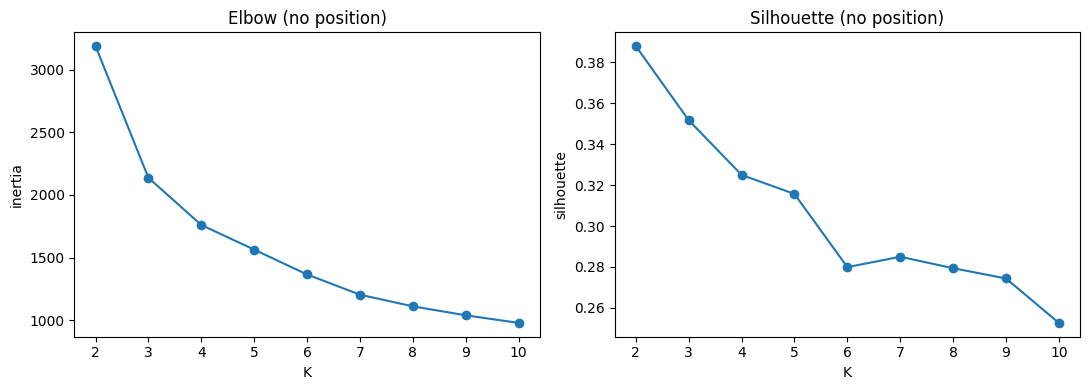

In [17]:
KMEANS_FEATURES_NO_POS = [
    "mean_minutes_per_gw",
    "mean_influence_per_app",
    "mean_creativity_per_app",
    "mean_threat_per_app",
    "mean_value",
]

scaler_np = StandardScaler().fit(train_agg[KMEANS_FEATURES_NO_POS].values)
X_train_np = scaler_np.transform(train_agg[KMEANS_FEATURES_NO_POS].values)

inertias_np, silhouettes_np = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lab = km.fit_predict(X_train_np)
    inertias_np.append(km.inertia_)
    silhouettes_np.append(silhouette_score(X_train_np, lab))
    print(f"K={k}: inertia={km.inertia_:.1f}, silhouette={silhouettes_np[-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ks, inertias_np, "o-"); axes[0].set_xlabel("K"); axes[0].set_ylabel("inertia"); axes[0].set_title("Elbow (no position)")
axes[1].plot(ks, silhouettes_np, "o-"); axes[1].set_xlabel("K"); axes[1].set_ylabel("silhouette"); axes[1].set_title("Silhouette (no position)")
plt.tight_layout(); plt.show()

In [20]:
km4 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_train_np)
train_agg["cluster_k4_nopos"] = km4.labels_

print("Cluster size and position composition:")
composition = (
    train_agg.groupby("cluster_k4_nopos")
    .agg(
        n=("name_key", "size"),
        pct_GK=("position", lambda s: (s == "GK").mean()),
        pct_DEF=("position", lambda s: (s == "DEF").mean()),
        pct_MID=("position", lambda s: (s == "MID").mean()),
        pct_FWD=("position", lambda s: (s == "FWD").mean()),
    ).round(2)
)
print(composition)

print("\nFeature means per cluster:")
print(
    train_agg.groupby("cluster_k4_nopos")[
        ["mean_minutes_per_gw", "mean_influence_per_app",
         "mean_creativity_per_app", "mean_threat_per_app", "mean_value"]
    ].mean().round(2)
)

print("\nExample players per cluster (top by mean_value):")
for c in sorted(train_agg["cluster_k4_nopos"].unique()):
    sample = train_agg[train_agg["cluster_k4_nopos"] == c].nlargest(5, "mean_value")
    print(f"\nCluster {c}:")
    print(sample[["name", "season", "position", "mean_value",
                  "mean_minutes_per_gw", "mean_threat_per_app"]].to_string(index=False))

Cluster size and position composition:
                    n  pct_GK  pct_DEF  pct_MID  pct_FWD
cluster_k4_nopos                                        
0                 326    0.17     0.71     0.12     0.00
1                 294    0.00     0.18     0.62     0.20
2                  88    0.00     0.03     0.58     0.39
3                 212    0.00     0.20     0.68     0.12

Feature means per cluster:
                  mean_minutes_per_gw  mean_influence_per_app  mean_creativity_per_app  mean_threat_per_app  mean_value
cluster_k4_nopos                                                                                                       
0                               80.62                   17.15                     4.44                 4.59       46.38
1                               39.63                    6.73                     5.77                 7.15       50.32
2                               73.20                   19.70                    17.87                29.94    

In [21]:
# Lock the final K-means model
K = 4
km_final = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_train_np)

# Train cluster labels: from K-means fit
train_lookup = train_agg[["name_key", "season", "cluster_k4_nopos"]].rename(
    columns={"cluster_k4_nopos": "cluster_id"}
)

# 23/24 assignment via prior-season aggregates
agg_2324 = player_season_aggregates("2023-24")
agg_2324 = agg_2324[agg_2324["gws_played"] >= 5].copy()

# For each name_key, take their most recent prior-season aggregates
prior_for_2324 = (
    train_agg[["name_key", "season"] + KMEANS_FEATURES_NO_POS]
    .sort_values("season", ascending=False)
    .drop_duplicates("name_key")
    .drop(columns=["season"])
)

candidates_2324 = (
    agg_2324[["name_key", "season"]]
    .merge(prior_for_2324, on="name_key", how="left")
)

has_prior = candidates_2324[KMEANS_FEATURES_NO_POS].notna().all(axis=1)
X_2324 = scaler_np.transform(
    candidates_2324.loc[has_prior, KMEANS_FEATURES_NO_POS].values
)
candidates_2324.loc[has_prior, "cluster_id"] = km_final.predict(X_2324)
candidates_2324.loc[~has_prior, "cluster_id"] = K  # unclassified bucket

print(f"23/24 player-seasons: {len(candidates_2324)}")
print(f"  assigned via prior history: {has_prior.sum()}")
print(f"  unclassified:               {(~has_prior).sum()}")

# Combine all per-(name_key, season) cluster lookups
cluster_lookup = pd.concat([
    train_lookup,
    candidates_2324[["name_key", "season", "cluster_id"]],
], ignore_index=True)

# Merge into df. Rows with fewer than 5 GWs in their season are absent from
# both lookups and fall through to the unclassified bucket via fillna.
df = df.merge(cluster_lookup, on=["name_key", "season"], how="left")
df["cluster_id"] = df["cluster_id"].fillna(K).astype(int)

# Acceptance checks
assert df["cluster_id"].isna().sum() == 0
assert set(df["cluster_id"].unique()) <= set(range(K + 1))
print(f"\ncluster_id distribution (rows in df):")
print(df["cluster_id"].value_counts().sort_index().to_string())
print(f"\nshape: {df.shape}")

23/24 player-seasons: 490
  assigned via prior history: 325
  unclassified:               165

cluster_id distribution (rows in df):
cluster_id
0    15140
1    13333
2     3991
3     9612
4    32401

shape: (74477, 56)


In [22]:
# Cluster summary (the writeup deliverable for the unsupervised section)
CLUSTER_NAMES = {
    0: "Defensive starters",
    1: "Rotational / fringe",
    2: "Premium attackers",
    3: "Creative regulars",
    K: "Unclassified",
}
df["cluster_name"] = df["cluster_id"].map(CLUSTER_NAMES)

summary = (
    df.groupby(["cluster_id", "cluster_name"])
      .agg(
          n_rows=("total_points", "size"),
          mean_points=("total_points", "mean"),
          mean_value=("value", "mean"),
          pct_GK=("pos_GK", "mean"),
          pct_DEF=("pos_DEF", "mean"),
          pct_MID=("pos_MID", "mean"),
          pct_FWD=("pos_FWD", "mean"),
      )
      .round(2)
)
print(summary)

                                n_rows  mean_points  mean_value  pct_GK  pct_DEF  pct_MID  pct_FWD
cluster_id cluster_name                                                                           
0          Defensive starters    15140         1.94       46.42    0.16     0.72     0.12     0.00
1          Rotational / fringe   13333         1.14       49.78    0.00     0.19     0.61     0.20
2          Premium attackers      3991         3.81       82.81    0.00     0.03     0.60     0.37
3          Creative regulars      9612         2.54       54.42    0.00     0.20     0.70     0.10
4          Unclassified          32401         0.23       44.92    0.18     0.29     0.39     0.13


In [23]:
# Decompose the unclassified bucket
unclassified = df[df["cluster_id"] == K].copy()
print(f"Total unclassified rows: {len(unclassified)}")
print(f"\nBy season:")
print(unclassified["season"].value_counts().sort_index().to_string())

# How many distinct player-seasons fall in unclassified?
print(f"\nDistinct unclassified player-seasons: {unclassified['player_season'].nunique()}")

# For 23/24 unclassified rows: are these the truly-new players, or established players with <5 GWs?
unc_2324 = unclassified[unclassified["season"] == "2023-24"]
prior_keys = set(train_agg["name_key"])
unc_2324_seasons = unc_2324[["name_key", "player_season"]].drop_duplicates()
unc_2324_seasons["had_prior_history"] = unc_2324_seasons["name_key"].isin(prior_keys)
print(f"\n23/24 unclassified player-seasons:")
print(unc_2324_seasons["had_prior_history"].value_counts().to_string())

# Sample some unclassified rows from each season to eyeball
print(f"\nSample unclassified players per season (top by row count):")
for season in SEASONS:
    sample = (
        unclassified[unclassified["season"] == season]
        .groupby("name").size().nlargest(5)
    )
    print(f"\n{season}:")
    print(sample.to_string())

Total unclassified rows: 32401

By season:
season
2021-22     7718
2022-23     8440
2023-24    16243

Distinct unclassified player-seasons: 1128

23/24 unclassified player-seasons:
had_prior_history
False    455
True      85

Sample unclassified players per season (top by row count):

2021-22:
name
Alphonse Areola    36
Benjamin Mendy     36
Cole Palmer        36
Conor Coventry     36
Darren Randolph    36

2022-23:
name
Alex Mighten              36
Alfie Devine              36
Allan Marques Loureiro    36
Andros Townsend           36
André Tavares Gomes       36

2023-24:
name
Aleksandar Mitrović       37
Alex Mighten              37
Anthony Knockaert         37
Bertrand Traoré           37
Braian Ojeda Rodríguez    37
